# Thesis Figure 3 â€” Sliding-Window Segment Scoring

Shows **how each segment is scored** during the initial scan:
for segment *i*, the model sees the image with segment *i* **and all its
immediate neighbours** replaced by the replacement colour;
the resulting log-odds drop is the score.

Two figures are produced:
1. **Composite overview** â€” full replacement image tinted by score (RdBu_r) with
   numeric score labels at segment centroids.
2. **Example grid** â€” N selected segments, each shown as three panels side-by-side:
   *original image* | *segmented image* | *window replaced + score label*.
   A yellow rectangle highlights the window area in the first two panels.

Edit only the **Configuration** cell.

In [8]:
# â”€â”€ Configuration â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
IMAGE_PATH = r"REPO_ROOT/images\\images\\imagenets_0082.jpg"

OVERRIDES = [
    "segmentation=slic",  # hexagonal | slic | square
    "segmentation.n_segments=300",  # e.g. hex_radius for hexagonal
    "segmentation.compactness=20",
    "replacement=imagenet_mean",
]

TARGET_CLASS_IDX = None  # None â†’ top-1 predicted class
NEIGHBORHOOD_DIST = 1  # BFS distance when building each window mask
BATCH_SIZE = 16

# â”€â”€ Composite figure settings â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Minimum pixel area a segment must have for its score to be shown as text
MIN_LABEL_AREA = 80
LABEL_FONTSIZE = 5
SCORE_ALPHA = 0.6  # opacity of the RdBu_r tint layer

# â”€â”€ Example-grid settings â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Segments to show (list of int IDs).
# None â†’ auto-select: 3 highest-score + 3 lowest-score + 3 near-zero-score
EXAMPLE_SEGMENTS = None

# Colour of the window-area rectangle in the first two panels
FRAME_COLOR = "yellow"

OUTPUT_DIR = "output"

In [9]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra
from hydra.utils import instantiate


REPO_ROOT = Path("../..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from ciao.data.preprocessing import load_and_preprocess_image
from ciao.model.predictor import ModelPredictor
from ciao.scoring.region import log_odds_for_class
from ciao.scoring.segments import calculate_segment_scores, create_surrogate_dataset
from ciao.visualization.visualization import _segment_boundaries, _to_hwc


OUT = Path(OUTPUT_DIR)
OUT.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cpu


In [10]:
# â”€â”€ Load image, model and segmentation via Hydra â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
GlobalHydra.instance().clear()
with initialize_config_dir(config_dir=str(REPO_ROOT / "configs"), version_base=None):
    cfg = compose(config_name="base", overrides=OVERRIDES)

img_tensor = load_and_preprocess_image(IMAGE_PATH, device=device)
input_batch = img_tensor.unsqueeze(0)

segmentation_fn = instantiate(cfg.segmentation)
image_graph = segmentation_fn(img_tensor)

model = instantiate(cfg.model).to(device).eval()
class_names = instantiate(cfg.classes)
predictor = ModelPredictor(model=model, class_names=class_names)

replacement_fn = instantiate(cfg.replacement)
replacement_image = replacement_fn(img_tensor)

img_np = _to_hwc(input_batch)
repl_np = _to_hwc(replacement_image.unsqueeze(0))
segs = image_graph.segments.cpu().numpy()

boundaries = _segment_boundaries(segs)
seg_overlay_full = img_np.copy()
seg_overlay_full[boundaries] = 1.0

print(f"Segments: {image_graph.num_segments}")

Segments: 281


In [11]:
# â”€â”€ Run model & compute surrogate scores â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
with torch.no_grad():
    logits = predictor.get_logits(input_batch)

if TARGET_CLASS_IDX is None:
    target_class_idx = int(logits.argmax(dim=1)[0].item())
else:
    target_class_idx = TARGET_CLASS_IDX

class_label = class_names[target_class_idx] if class_names else str(target_class_idx)
prob = float(torch.softmax(logits, dim=1)[0, target_class_idx].item())
print(f"Target class: [{target_class_idx}] {class_label}  (p = {prob:.3f})")

original_log_odds = log_odds_for_class(logits, target_class_idx)

print("Computing surrogate datasetâ€¦")
X, y = create_surrogate_dataset(
    predictor=predictor,
    input_batch=input_batch,
    replacement_image=replacement_image,
    image_graph=image_graph,
    target_class_idx=target_class_idx,
    original_log_odds=original_log_odds,
    neighborhood_distance=NEIGHBORHOOD_DIST,
    batch_size=BATCH_SIZE,
)
scores = calculate_segment_scores(X, y)
score_vals = list(scores.values())
print(f"Score range: [{min(score_vals):.4f}, {max(score_vals):.4f}]")

Target class: [203] West Highland white terrier  (p = 0.930)
Computing surrogate datasetâ€¦
Score range: [-0.6303, 0.4691]


In [12]:
# â”€â”€ Shared helpers â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def centroid(seg_id: int) -> tuple[float, float]:
    ys, xs = np.where(segs == seg_id)
    return float(xs.mean()), float(ys.mean())


def window_mask(seg_id: int) -> np.ndarray:
    """Boolean [H, W] mask for segment seg_id and all its immediate neighbours."""
    ids = {seg_id} | set(image_graph.adj_list[seg_id])
    mask = np.zeros(segs.shape, dtype=bool)
    for sid in ids:
        mask |= segs == sid
    return mask


def window_image(seg_id: int) -> np.ndarray:
    """Full image with the window for seg_id replaced."""
    mask = window_mask(seg_id)
    out = img_np.copy()
    out[mask] = repl_np[mask]
    return out

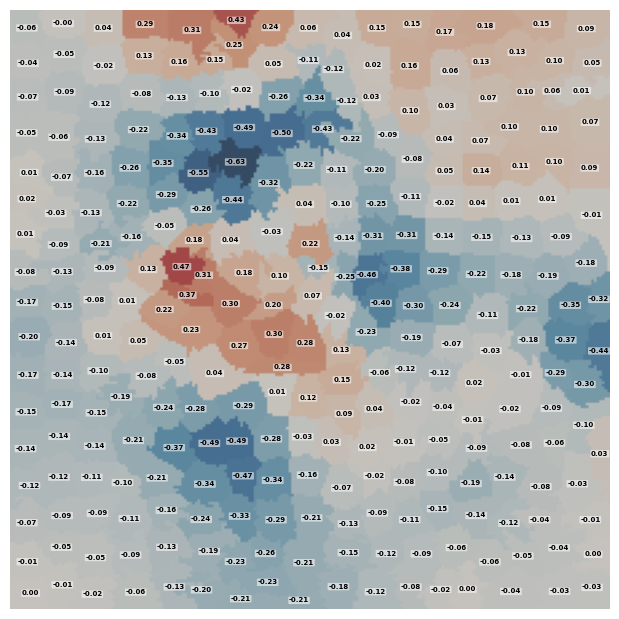

Saved â†’ output\sliding_window_composite.png


In [13]:
# â”€â”€ Figure 1: Composite overview â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
score_map = np.zeros(segs.shape, dtype=np.float32)
for seg_id, score in scores.items():
    score_map[segs == seg_id] = score
abs_max = float(np.abs(score_map).max()) or 1.0

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(repl_np)
ax.imshow(score_map, cmap="RdBu_r", vmin=-abs_max, vmax=abs_max, alpha=SCORE_ALPHA)
ax.axis("off")

for seg_id, score in scores.items():
    if int((segs == seg_id).sum()) < MIN_LABEL_AREA:
        continue
    cx, cy = centroid(seg_id)
    ax.text(
        cx,
        cy,
        f"{score:.2f}",
        fontsize=LABEL_FONTSIZE,
        ha="center",
        va="center",
        fontweight="bold",
        color="black",
        bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.55, lw=0),
        zorder=5,
    )

fig.tight_layout(pad=0)
fig.savefig(OUT / "sliding_window_composite.png", dpi=150, bbox_inches="tight")
fig.savefig(OUT / "sliding_window_composite.pdf", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved â†’ {OUT / 'sliding_window_composite.png'}")

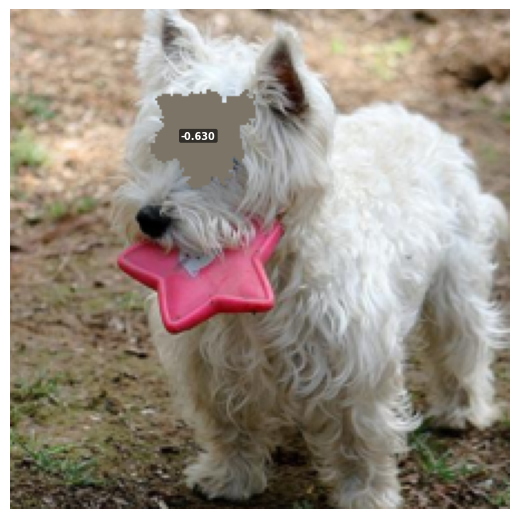

seg   66  score=-0.6303  â†’ window_seg66.png


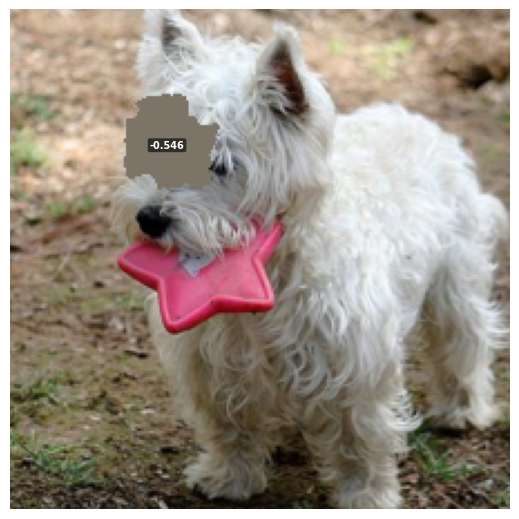

seg   77  score=-0.5459  â†’ window_seg77.png


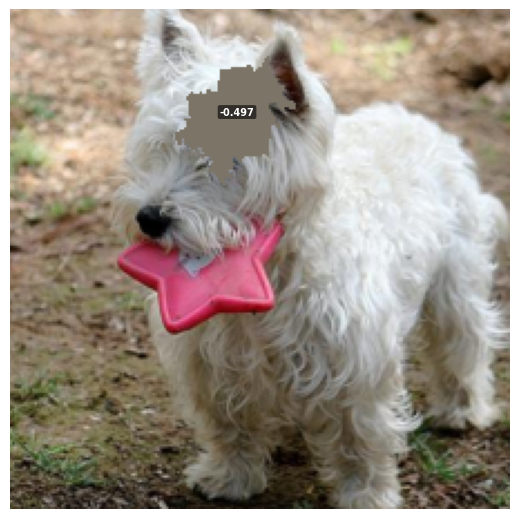

seg   52  score=-0.4966  â†’ window_seg52.png


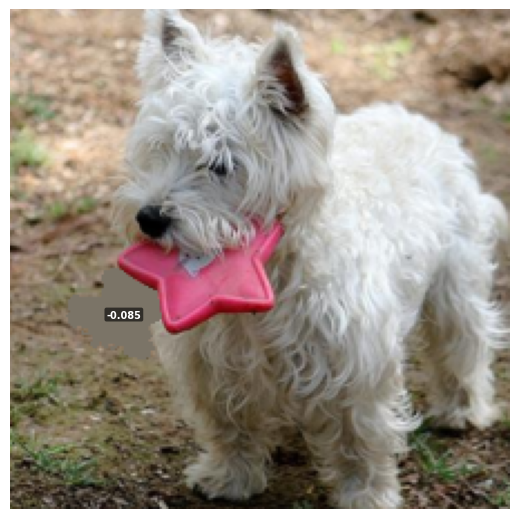

seg  171  score=-0.0848  â†’ window_seg171.png


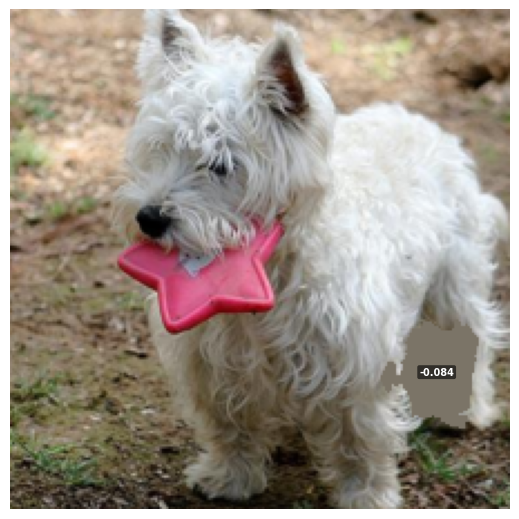

seg  208  score=-0.0835  â†’ window_seg208.png


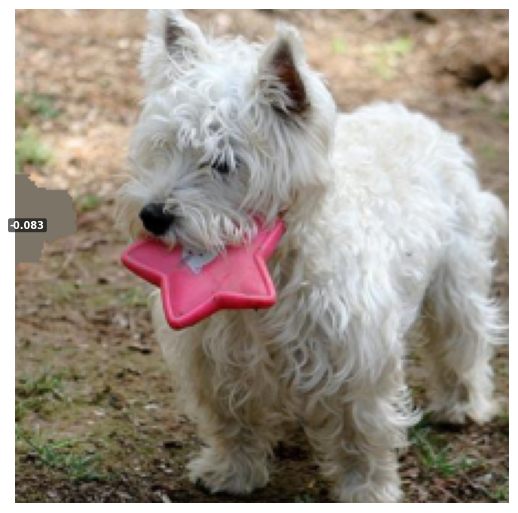

seg  118  score=-0.0831  â†’ window_seg118.png


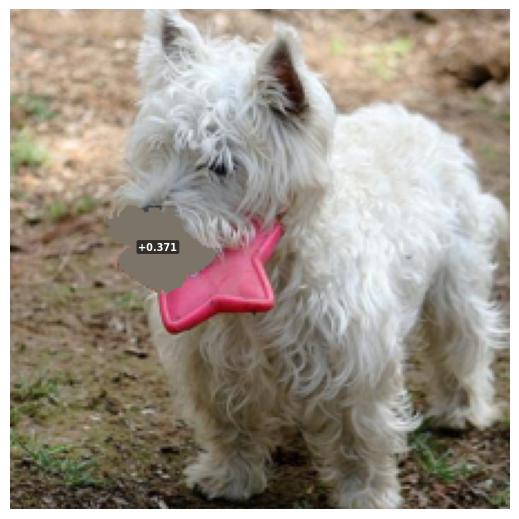

seg  136  score=+0.3710  â†’ window_seg136.png


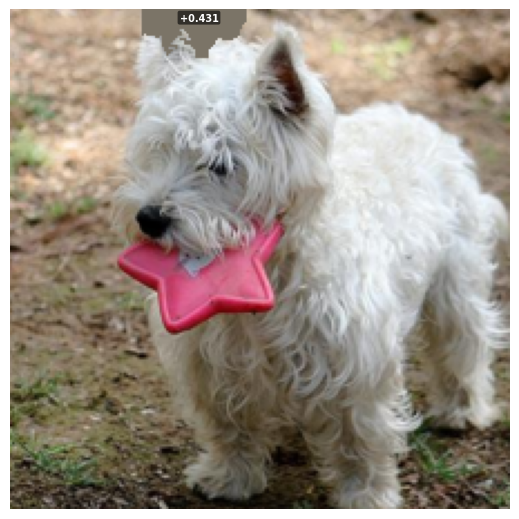

seg    5  score=+0.4306  â†’ window_seg5.png


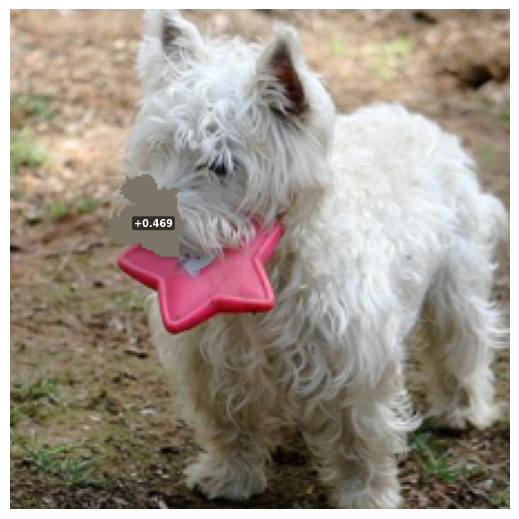

seg  116  score=+0.4691  â†’ window_seg116.png


In [14]:
# â”€â”€ Figure 2: Example windows â€” one file per segment â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def _auto_select(scores: dict, n: int = 3) -> list[int]:
    """Pick n highest, n lowest and n near-zero-score segment IDs."""
    sorted_ids = sorted(scores.keys(), key=lambda k: scores[k])
    high = sorted_ids[-n:]
    low = sorted_ids[:n]
    mid_i = len(sorted_ids) // 2
    mid = sorted_ids[mid_i - n // 2 : mid_i - n // 2 + n]
    seen, out = set(), []
    for k in low + mid + high:
        if k not in seen:
            seen.add(k)
            out.append(k)
    return out


example_ids = EXAMPLE_SEGMENTS if EXAMPLE_SEGMENTS is not None else _auto_select(scores)

for seg_id in example_ids:
    score = scores[seg_id]
    cx, cy = centroid(seg_id)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(window_image(seg_id))
    ax.text(
        cx,
        cy,
        f"{score:+.3f}",
        ha="center",
        va="center",
        fontsize=7,
        fontweight="bold",
        color="white",
        bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.6, lw=0),
        zorder=5,
    )
    ax.axis("off")
    fig.tight_layout(pad=0)
    fig.savefig(OUT / f"window_seg{seg_id}.png", dpi=150, bbox_inches="tight")
    fig.savefig(OUT / f"window_seg{seg_id}.pdf", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"seg {seg_id:4d}  score={score:+.4f}  â†’ window_seg{seg_id}.png")